<a href="https://colab.research.google.com/github/viswanath401/hybrid-qml-drug-discovery/blob/main/quantum_drug_discovery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
from google.colab import files
uploaded = files.upload()

Saving tox21.csv to tox21 (1).csv


In [26]:
import pandas as pd

df = pd.read_csv("tox21.csv")
df.head()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


In [27]:
print(df.shape)
print(df.columns)

(7831, 14)
Index(['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
       'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53',
       'mol_id', 'smiles'],
      dtype='object')


In [28]:
df = df[["smiles", "NR-AR"]]

In [29]:
df = df.rename(columns={"NR-AR": "label"})

In [30]:
print(df.isnull().sum())

smiles      0
label     566
dtype: int64


In [31]:
df = df.dropna()

In [32]:
print(df.shape)
df.head()

(7265, 2)


,smiles,label
0,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,0.0
1,CCN1C(=O)NC(c2ccccc2)C1=O,0.0
3,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C,0.0
4,CC(O)(P(=O)(O)O)P(=O)(O)O,0.0
5,CC(C)(C)OOC(C)(C)CCC(C)(C)OOC(C)(C)C,0.0


In [33]:
df["label"] = df["label"].astype(int)

In [34]:
print(df["label"].value_counts())

label
0    6956
1     309
Name: count, dtype: int64


In [35]:
df = df.reset_index(drop=True)

In [36]:
print(df.head())
print(df.dtypes)

                                 smiles  label
0          CCOc1ccc2nc(S(N)(=O)=O)sc2c1      0
1             CCN1C(=O)NC(c2ccccc2)C1=O      0
2       CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C      0
3             CC(O)(P(=O)(O)O)P(=O)(O)O      0
4  CC(C)(C)OOC(C)(C)CCC(C)(C)OOC(C)(C)C      0
smiles    object
label      int64
dtype: object


In [37]:
df.to_csv("clean_tox21.csv", index=False)

In [38]:
!pip install rdkit

In [39]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

In [40]:
def smiles_to_mol(smiles):
    return Chem.MolFromSmiles(smiles)

In [41]:
def mol_to_features(mol):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=128)
    return np.array(fp)

In [42]:
def process_smiles(smiles):
    mol = smiles_to_mol(smiles)
    if mol is None:
        return None
    return mol_to_features(mol)

In [43]:
features = []
valid_indices = []

for i, sm in enumerate(df["smiles"]):
    feat = process_smiles(sm)
    if feat is not None:
        features.append(feat)
        valid_indices.append(i)

Streaming output truncated to the last 5000 lines.
[13:26:58] DEPRECATION WARNING: please use MorganGenerator
[13:26:58] DEPRECATION WARNING: please use MorganGenerator
[13:26:58] DEPRECATION WARNING: please use MorganGenerator
[13:26:58] DEPRECATION WARNING: please use MorganGenerator
[13:26:58] DEPRECATION WARNING: please use MorganGenerator
[13:26:58] DEPRECATION WARNING: please use MorganGenerator
[13:26:58] DEPRECATION WARNING: please use MorganGenerator
[13:26:58] DEPRECATION WARNING: please use MorganGenerator
[13:26:58] DEPRECATION WARNING: please use MorganGenerator
[13:26:58] DEPRECATION WARNING: please use MorganGenerator
[13:26:58] DEPRECATION WARNING: please use MorganGenerator
[13:26:58] DEPRECATION WARNING: please use MorganGenerator
[13:26:58] DEPRECATION WARNING: please use MorganGenerator
[13:26:58] DEPRECATION WARNING: please use MorganGenerator
[13:26:58] DEPRECATION WARNING: please use MorganGenerator
[13:26:58] DEPRECATION WARNING: please use MorganGenerator
[13:2

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [47]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [49]:
X = np.array(features)
y = df.iloc[valid_indices]["label"].values

In [50]:
print(X.shape)
print(y.shape)

(7258, 128)
(7258,)


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [52]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (5806, 128)
Test: (1452, 128)


In [53]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [54]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [55]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9731404958677686


In [56]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1396
           1       0.87      0.36      0.51        56

    accuracy                           0.97      1452
   macro avg       0.92      0.68      0.75      1452
weighted avg       0.97      0.97      0.97      1452



In [57]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc)

ROC-AUC: 0.6718494167007777


In [58]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 33.1 MB/s eta 0:00:00


In [59]:
import pennylane as qml
from pennylane import numpy as np
import torch
import torch.nn as nn

In [60]:
dev = qml.device("default.qubit", wires=4)

In [61]:
@qml.qnode(dev)
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(4))
    qml.BasicEntanglerLayers(weights, wires=range(4))
    return [qml.expval(qml.PauliZ(i)) for i in range(4)]

In [62]:
weight_shapes = {"weights": (2, 4)}

In [63]:
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)


In [64]:
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(128, 4)   # reduce features
        self.quantum = quantum_layer
        self.fc2 = nn.Linear(4, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.quantum(x)
        x = self.fc2(x)
        return torch.sigmoid(x)

In [65]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

In [66]:
model = HybridModel()

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(10):
    optimizer.zero_grad()
    output = model(X_train_t).squeeze()
    loss = criterion(output, y_train_t)
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 0.47797539830207825
Epoch 2, Loss: 0.46215716004371643
Epoch 3, Loss: 0.4550180733203888
Epoch 4, Loss: 0.4495973289012909
Epoch 5, Loss: 0.44323208928108215
Epoch 6, Loss: 0.43576833605766296
Epoch 7, Loss: 0.4277086853981018
Epoch 8, Loss: 0.4195610582828522
Epoch 9, Loss: 0.41150641441345215
Epoch 10, Loss: 0.40396952629089355


In [67]:
with torch.no_grad():
    preds = model(X_test_t).squeeze().numpy()

from sklearn.metrics import roc_auc_score

roc = roc_auc_score(y_test, preds)
print("Quantum ROC-AUC:", roc)

Quantum ROC-AUC: 0.5689469914040115


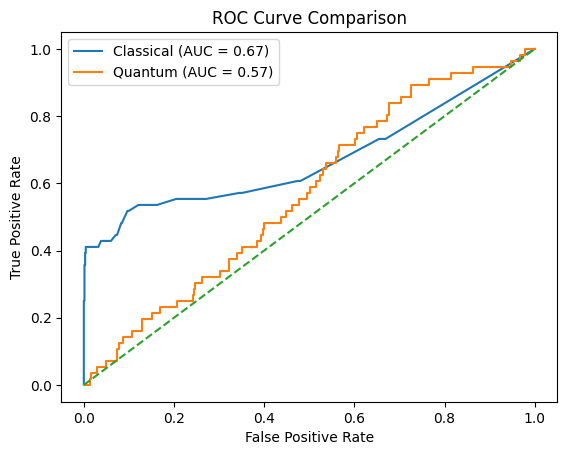

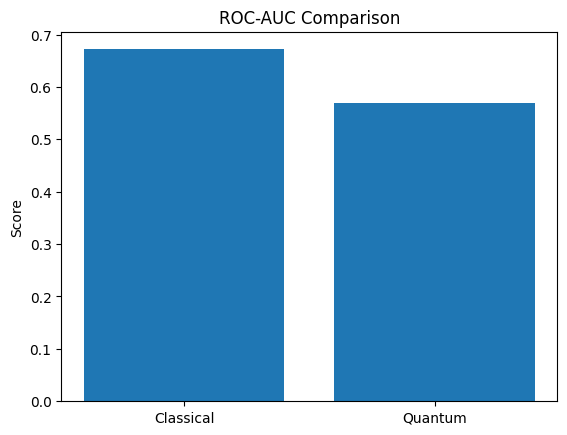

Final Results:
Classical ROC-AUC: 0.6718
Quantum ROC-AUC: 0.5689


In [68]:
# =========================
# FINAL ANALYSIS & VISUALIZATION
# =========================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# -------------------------
# 1. Classical Model ROC
# -------------------------
fpr_classical, tpr_classical, _ = roc_curve(y_test, y_prob)
roc_classical = auc(fpr_classical, tpr_classical)

# -------------------------
# 2. Quantum Model ROC
# -------------------------
fpr_quantum, tpr_quantum, _ = roc_curve(y_test, preds)
roc_quantum = auc(fpr_quantum, tpr_quantum)

# -------------------------
# 3. Plot ROC Curve
# -------------------------
plt.figure()
plt.plot(fpr_classical, tpr_classical, label=f'Classical (AUC = {roc_classical:.2f})')
plt.plot(fpr_quantum, tpr_quantum, label=f'Quantum (AUC = {roc_quantum:.2f})')

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# -------------------------
# 4. Bar Chart Comparison
# -------------------------
models = ["Classical", "Quantum"]
roc_scores = [roc_classical, roc_quantum]

plt.figure()
plt.bar(models, roc_scores)
plt.title("ROC-AUC Comparison")
plt.ylabel("Score")
plt.show()

# -------------------------
# 5. Print Final Results
# -------------------------
print("Final Results:")
print(f"Classical ROC-AUC: {roc_classical:.4f}")
print(f"Quantum ROC-AUC: {roc_quantum:.4f}")